<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch16_deep_learning_outlier_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 16 -- Deep Learning-Based Outlier Detection

This notebook accompanies **Chapter 16** of *Outlier Detection in Python* (Manning). It is a hands-on tour of how **deep neural networks** are used to detect anomalies, covering three families of methods and two modalities (tabular and image).

**What we will cover**

1. A brief primer on neural networks to fix notation and vocabulary.
2. **Reconstruction-based methods** -- *autoencoders* (AE) and *variational autoencoders* (VAE), where anomalies are records the network cannot compress and reconstruct well.
3. **Generative/adversarial methods** -- GANs, BiGAN-based detectors (AnoGAN, ALAD), and the GAAL family (SO_GAAL, MO_GAAL).
4. **Purpose-built deep detectors** -- DeepSVDD and Deep Isolation Forest.
5. **Image data** -- what makes it different (*out-of-distribution* detection) and a worked example on CIFAR-10 using `alibi-detect`.
6. **Self-supervised learning for tabular data** -- embeddings, transfer learning, and the methods that power the current research frontier (GOAD, ICL) through the `DeepOD` library.

**Running environment.** Several code cells require `tensorflow` or `torch`, which are pre-installed on Google Colab but may not be present on every local environment. Cells are marked as *Run on Colab* where that is the case, with expected outputs pre-filled from the textbook so the narrative remains complete.

**A positioning note before we start.** Deep learning is the *only* viable tool for outlier detection in image, video, and audio today. For tabular data, however, classical methods (Isolation Forest, LOF, KNN, GMM, and the like) typically remain stronger, faster, and easier to tune. The value of this chapter is therefore twofold: (i) it unlocks modalities where classical methods cannot go at all, and (ii) it provides a second, architecturally diverse family of tabular detectors that contributes meaningfully to *ensembles* even when individual accuracy is no better than a well-tuned Isolation Forest.

## Setup

Deep learning outlier detection in Python is dominated by three libraries:

- **PyOD** -- provides AE, VAE, AnoGAN, ALAD, SO_GAAL, MO_GAAL, DeepSVDD, DIF under a single unified API (the same one used by the classical detectors in earlier chapters).
- **alibi-detect** -- image-friendly, with first-class support for convolutional AE/VAE and Gaussian-mixture extensions (AEGMM, VAEGMM).
- **DeepOD** -- the most research-current of the three; it bundles self-supervised detectors such as GOAD and ICL alongside the standard ones.

PyOD dispatches internally to either TensorFlow/Keras or PyTorch depending on the detector, so on a fresh environment you will usually want both deep-learning frameworks available.

In [3]:
# Colab ships numpy 2.x; many deep-learning libs (numba in particular) cap numpy at <2.0
# via import-time checks. Pinning numpy to 1.26.4 satisfies every transitive dependency
# in this notebook. Pin numpy FIRST, then install the outlier-detection libs so their
# resolvers respect the pin.
!pip install -q "numpy==1.26.4"
!pip install -q pyod alibi-detect deepod

# Clear the numpy / numba / llvmlite / scipy modules from sys.modules so the pinned
# versions take effect without a runtime restart. If you still see
# "Numba needs NumPy 1.26 or less" after this cell, do Runtime -> Restart session.
import sys
for mod in list(sys.modules):
    if mod.startswith(("numpy", "numba", "llvmlite", "scipy")):
        del sys.modules[mod]

import numpy, numba
print(f"numpy {numpy.__version__}  |  numba {numba.__version__}  ->  compatible")

numpy 1.26.4  |  numba 0.59.1  ->  compatible


/tmp/ipykernel_10009/419927261.py:16: UserWarning: The NumPy module was reloaded (imported a second time). This can in some cases result in small but subtle issues and is discouraged.
  import numpy, numba


In [ ]:
# 1. Buang numpy yang di-pin, biar Colab kembali ke numpy 2.x default-nya.
!pip uninstall -y -q numpy

# 2. Install ulang numpy + numba versi terbaru (numba 0.61+ mendukung numpy 2.x).
!pip install -q --upgrade numpy numba llvmlite

# 3. Install deep-learning outlier detection libs.
!pip install -q pyod alibi-detect deepod

print("Install selesai. Sekarang WAJIB restart runtime:")
print("  Runtime -> Restart session (atau Ctrl+M .)")
print("Setelah restart, JANGAN jalankan cell ini lagi.")
print("Langsung lanjut ke cell imports berikutnya.")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

np.random.seed(0)
print("Environment ready.")

Environment ready.


## 16.1 Introducing Neural Networks

Before we can reason about AE-, VAE-, or GAN-based detectors, it is worth fixing the mental model of what a neural network actually *does*.

A **neural network** is a stack of layers of **neurons**. Each neuron $j$ in layer $\ell$ computes its own scalar value $a_j^{(\ell)}$ from the values of the previous layer:

$$a_j^{(\ell)} = \sigma\!\left( \sum_{i} w_{ji}^{(\ell)} \, a_i^{(\ell-1)} + b_j^{(\ell)} \right)$$

where $w_{ji}^{(\ell)}$ are the **weights**, $b_j^{(\ell)}$ is the **bias**, and $\sigma(\cdot)$ is a nonlinear **activation function** (commonly ReLU, sigmoid, or tanh). The inputs to the very first layer are the raw features (pixel values, table columns, token indices, etc.), and the final layer's values are the network's **prediction**.

**Intuition.** Each layer computes a new, richer representation of the input. Early layers learn simple patterns (edges, cell-wise ranges); deep layers combine those into abstract concepts (faces, sentiments, "unusual login sequence"). The word **deep** in *deep learning* just means *many layers* -- typically more than three or four.

For this chapter, the key property is: **deep networks can learn arbitrarily complex, nonlinear functions of their inputs given enough data.** That is what makes them usable for pixel-level image data and for tables with hundreds of interacting features -- regimes where classical detectors that treat every feature as a flat coordinate struggle.

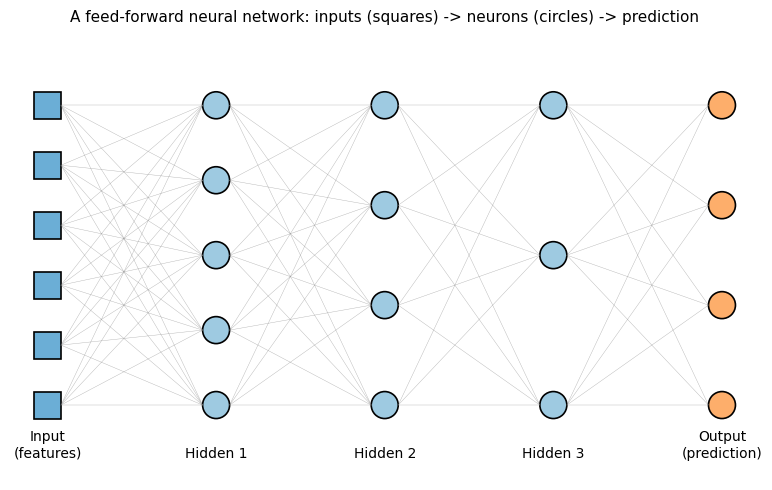

In [3]:
# Visualize a small fully-connected network to match Figure 16.1 from the chapter.
fig, ax = plt.subplots(figsize=(10, 5))

layer_sizes = [6, 5, 4, 3, 4]   # input + 3 hidden + output
x_positions = np.linspace(0.5, 9.5, len(layer_sizes))
colors = ['#6baed6', '#9ecae1', '#9ecae1', '#9ecae1', '#fdae6b']

positions = []
for li, (size, x, color) in enumerate(zip(layer_sizes, x_positions, colors)):
    ys = np.linspace(1, 5, size)
    layer_pos = []
    for y in ys:
        if li == 0:
            ax.add_patch(plt.Rectangle((x - 0.18, y - 0.18), 0.36, 0.36,
                                        facecolor=color, edgecolor='black', lw=1.2))
        else:
            ax.add_patch(plt.Circle((x, y), 0.18, facecolor=color, edgecolor='black', lw=1.2))
        layer_pos.append((x, y))
    positions.append(layer_pos)

# Draw connections between consecutive layers
for left, right in zip(positions[:-1], positions[1:]):
    for (x1, y1) in left:
        for (x2, y2) in right:
            ax.plot([x1 + 0.18, x2 - 0.18], [y1, y2], color='gray', lw=0.3, alpha=0.6)

labels = ['Input\n(features)', 'Hidden 1', 'Hidden 2', 'Hidden 3', 'Output\n(prediction)']
for x, lab in zip(x_positions, labels):
    ax.text(x, 0.3, lab, ha='center', fontsize=10)

ax.set_xlim(0, 10); ax.set_ylim(0, 6)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title("A feed-forward neural network: inputs (squares) -> neurons (circles) -> prediction",
             fontsize=11)
plt.tight_layout(); plt.show()

The figure above mirrors **Figure 16.1** of the chapter. Reading left to right: each input feature feeds every neuron in the first hidden layer; each hidden layer feeds the next; and the final output layer produces the prediction. For a four-class classifier (cat/dog/horse/goat), the four output neurons would hold the predicted probabilities of each class. For a **regressor**, the output layer would hold a single real value; for an **autoencoder**, as we will see next, the output layer would have *exactly as many neurons as the input*.

**Why this matters for outlier detection.** Every deep detector in this chapter is obtained by shaping the network in a specific way -- forcing the input back through a bottleneck (AE), pairing the encoder with a probabilistic latent space (VAE), or playing two networks off each other (GAN). The *scoring rule* for "outlier" then becomes whatever quantity the architecture makes natural: reconstruction error, discriminator probability, or distance in latent space.

## 16.2 PyOD: Deep Detectors Under a Familiar API

PyOD, which we used extensively in earlier chapters, also exposes a set of deep-learning detectors. They all follow the same `fit -> decision_scores_ / predict / predict_proba` API as `IForest`, `LOF`, `KNN`, etc., so swapping one in is a one-line change. Internally, each detector is implemented on top of either **TensorFlow/Keras** or **PyTorch**.

Before trying each detector, we first load the dataset used throughout this section: the **KDD Cup 1999** intrusion-detection subset (`SA`, 10%). This dataset is frequently used to benchmark outlier detectors because it is large, mostly clean traffic, and contains a small fraction of labeled intrusions we can use as pseudo-ground-truth.

**API compatibility note.** PyOD 2.x renamed the training-length parameter for `AutoEncoder` and `VAE` from `epochs` (as it appeared in the textbook) to `epoch_num`. The other deep detectors in this chapter (`ALAD`, `SO_GAAL`, `MO_GAAL`, `DeepSVDD`) kept their original parameter names. The cells below use the current PyOD API.

### Listing 16.1 -- Loading the KDD Cup dataset

In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import OrdinalEncoder

np.random.seed(0)

X, y = fetch_kddcup99(subset="SA", percent10=True, random_state=42,
                     return_X_y=True, as_frame=True)

# Binary target: 1 if the record is any kind of attack, 0 if it is 'normal.'
y = (y != b"normal.").astype(np.int32)

# KDD Cup has several categorical columns ('protocol_type', 'service', 'flag').
# OrdinalEncoder turns them into integers so numeric models can consume them.
enc = OrdinalEncoder()
X = enc.fit_transform(X)

print("X shape       :", X.shape)
print("Outlier rate  :", f"{y.mean() * 100:.2f}%")
print("Normal / Attack:", (y == 0).sum(), "/", (y == 1).sum())

X shape       : (100655, 41)
Outlier rate  : 3.36%
Normal / Attack: 97278 / 3377


The `SA` 10% subset contains **100,655 records with 41 features**. Note the label distribution: roughly **96.65% "attacks" and 3.35% "normal."** The naming is counter-intuitive -- in this benchmark we treat `normal.` as the *reference class* and every other label as the anomaly we want to flag. Some analyses invert this framing and treat attacks as normal; either convention works as long as the evaluation is consistent.

**Dimensionality.** With $p = 41$ features and $n = 100{,}655$ rows, we sit comfortably in the $n \gg p$ regime. This is a good setting for deep models: they have enough data to learn the joint distribution of features without memorizing, and classical detectors such as Isolation Forest have a clear yardstick to beat.

**Ordinal encoding.** The `OrdinalEncoder` is a deliberate simplification. Strict best practice for categorical features going into a *linear* model is one-hot or target encoding. For tree-based and neural-network-based detectors, ordinal encoding is usually acceptable -- the network can learn its own embedding of each category from the integer code. We make the trade-off here for speed and simplicity; one-hot would push the feature count from 41 to $\sim 120$ and slow every subsequent fit.

### 16.2.1 Autoencoders

An **autoencoder** (AE) is a neural network trained to reproduce its input. Formally, it is a pair of functions

$$\mathbf{z} = f_\phi(\mathbf{x}) \qquad \hat{\mathbf{x}} = g_\theta(\mathbf{z})$$

where $f_\phi: \mathbb{R}^p \to \mathbb{R}^d$ is the **encoder** (parameters $\phi$), $g_\theta: \mathbb{R}^d \to \mathbb{R}^p$ is the **decoder** (parameters $\theta$), and the **bottleneck** $\mathbf{z}$ lives in a much lower-dimensional space: $d \ll p$. The network is trained to minimise the **reconstruction loss**

$$\mathcal{L}(\phi, \theta) = \frac{1}{N} \sum_{i=1}^{N} \| \mathbf{x}_i - g_\theta(f_\phi(\mathbf{x}_i)) \|_2^2$$

for some distance (usually squared $\ell_2$, occasionally $\ell_1$ or cosine).

**Why this detects outliers.** The bottleneck $\mathbf{z} \in \mathbb{R}^d$ cannot hold everything about $\mathbf{x}$; the network must therefore learn *which regularities of the training data are worth preserving*. Typical records fit those regularities and reconstruct with small error; atypical records do not and reconstruct poorly. The **per-record reconstruction error**

$$s(\mathbf{x}) = \| \mathbf{x} - g_\theta(f_\phi(\mathbf{x})) \|_2^2$$

is therefore a natural outlier score.

**Sizing the bottleneck.** This is the main knob. If $d$ is *too large*, the identity function is learnable and every record reconstructs perfectly -- leaving no signal. If $d$ is *too small*, even typical records reconstruct poorly and the outlier signal gets drowned in noise. The practical recipe is to start wide and shrink until most records reconstruct well but not perfectly.

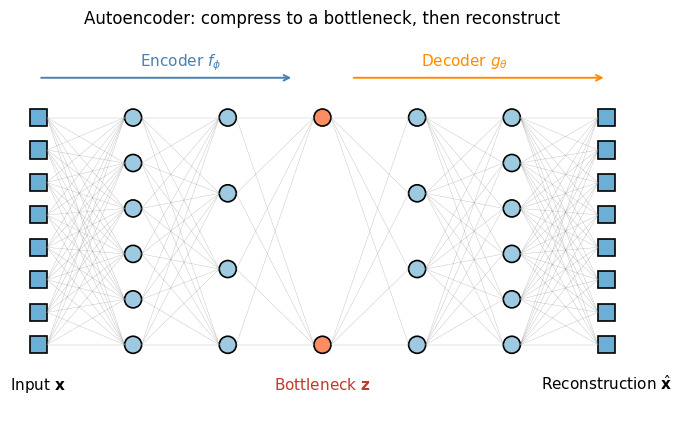

In [5]:
# Visualize an autoencoder architecture: symmetric encoder + decoder with a bottleneck.
fig, ax = plt.subplots(figsize=(11, 4.5))

layer_sizes = [8, 6, 4, 2, 4, 6, 8]  # symmetric around the 2-neuron bottleneck
x_positions = np.linspace(0.5, 10.5, len(layer_sizes))
bottleneck_idx = len(layer_sizes) // 2

positions = []
for li, (size, x) in enumerate(zip(layer_sizes, x_positions)):
    ys = np.linspace(0.5, 4.5, size)
    color = '#fc8d62' if li == bottleneck_idx else ('#6baed6' if li == 0 or li == len(layer_sizes) - 1 else '#9ecae1')
    layer_pos = []
    for y in ys:
        if li == 0 or li == len(layer_sizes) - 1:
            ax.add_patch(plt.Rectangle((x - 0.15, y - 0.15), 0.3, 0.3,
                                        facecolor=color, edgecolor='black', lw=1.2))
        else:
            ax.add_patch(plt.Circle((x, y), 0.15, facecolor=color, edgecolor='black', lw=1.2))
        layer_pos.append((x, y))
    positions.append(layer_pos)

for left, right in zip(positions[:-1], positions[1:]):
    for (x1, y1) in left:
        for (x2, y2) in right:
            ax.plot([x1 + 0.15, x2 - 0.15], [y1, y2], color='gray', lw=0.3, alpha=0.5)

# Encoder / decoder / bottleneck labels
ax.annotate('', xy=(x_positions[bottleneck_idx] - 0.5, 5.2),
            xytext=(x_positions[0], 5.2),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.4))
ax.text((x_positions[0] + x_positions[bottleneck_idx]) / 2, 5.4,
        'Encoder $f_\\phi$', ha='center', color='steelblue', fontsize=11)

ax.annotate('', xy=(x_positions[-1], 5.2),
            xytext=(x_positions[bottleneck_idx] + 0.5, 5.2),
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.4))
ax.text((x_positions[bottleneck_idx] + x_positions[-1]) / 2, 5.4,
        'Decoder $g_\\theta$', ha='center', color='darkorange', fontsize=11)

ax.text(x_positions[bottleneck_idx], -0.3,
        'Bottleneck $\\mathbf{z}$',
        ha='center', color='#c0392b', fontsize=11)
ax.text(x_positions[0], -0.3, 'Input $\\mathbf{x}$', ha='center', fontsize=11)
ax.text(x_positions[-1], -0.3, 'Reconstruction $\\hat{\\mathbf{x}}$', ha='center', fontsize=11)

ax.set_xlim(0, 11); ax.set_ylim(-1, 6)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Autoencoder: compress to a bottleneck, then reconstruct', fontsize=12)
plt.tight_layout(); plt.show()

The diagram mirrors **Figure 16.2** in the chapter. The encoder squeezes an 8-dimensional input down to a 2-neuron **bottleneck**, then the decoder expands it back to 8 dimensions. In practice $p$ is the number of table columns (41 for KDD Cup) and $d$ is chosen by the practitioner -- typical values are between 10% and 50% of $p$.

**Two complementary outputs.** Once an AE is trained we actually get *two* different objects we can use for outlier detection:

1. **Reconstruction error** $\|\mathbf{x} - \hat{\mathbf{x}}\|$ -- the standard signal.
2. **The bottleneck vector** $\mathbf{z} = f_\phi(\mathbf{x})$ itself -- a low-dimensional embedding that we can feed into a *classical* detector (KNN, Isolation Forest, Mahalanobis) for a second opinion.

With $d = 2$ or $d = 3$ we can even plot the latent space as a scatter and look at anomalies visually -- the closest thing to an interpretable deep outlier detector.

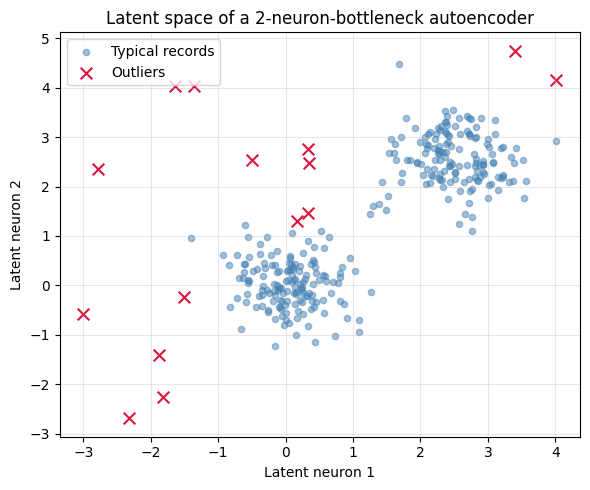

In [6]:
# Illustrate the idea of the 2D latent space: most points form a dense manifold,
# outliers sit clearly outside it. Using a synthetic example since we do not
# actually fit an AE yet.
from sklearn.datasets import make_blobs

np.random.seed(1)
latent_normal, _ = make_blobs(n_samples=300, centers=[[0, 0], [2.5, 2.5]],
                              cluster_std=0.5, random_state=1)
latent_outliers = np.random.uniform(low=-3, high=5, size=(15, 2))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(latent_normal[:, 0], latent_normal[:, 1],
           s=20, alpha=0.5, c='steelblue', label='Typical records')
ax.scatter(latent_outliers[:, 0], latent_outliers[:, 1],
           s=70, marker='x', c='crimson', label='Outliers')
ax.set_xlabel('Latent neuron 1'); ax.set_ylabel('Latent neuron 2')
ax.set_title('Latent space of a 2-neuron-bottleneck autoencoder')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

This mirrors **Figure 16.3** in the chapter. The **300 typical records** cluster into two dense blobs (the "manifold" of normal traffic) while the **15 outliers**, scattered uniformly in the same box, sit visibly outside those blobs. A classical detector such as KNN or Isolation Forest run *on the latent coordinates* would flag them immediately.

**Takeaway for practice.** When the bottleneck is 2- or 3-dimensional, the latent scatter is a free diagnostic tool: you can eyeball whether the AE has learned a meaningful structure, or whether it is just projecting everything into a single blob (which would mean no signal for outlier detection).

### Listing 16.2 -- PyOD's AutoEncoder detector

PyOD wraps the whole pipeline -- architecture, training loop, scoring -- behind the standard `fit / predict_proba` interface.

In [7]:
# Run on Colab with TensorFlow or PyTorch available.
# PyOD's AutoEncoder internally builds a symmetric network and trains on reconstruction loss.
from pyod.models.auto_encoder import AutoEncoder

np.random.seed(0)
det_ae = AutoEncoder(epoch_num=5, random_state=0)
det_ae.fit(X)
pred_ae = det_ae.predict_proba(X)[:, 1]

print("Outlier scores for first 5 records:", np.round(pred_ae[:5], 4))
print("Mean outlier probability:", pred_ae.mean().round(4))
print("Flagged as outliers (default threshold):", (det_ae.predict(X) == 1).sum(),
      f"out of {len(X)}")

Training: 100%|██████████| 5/5 [00:57<00:00, 11.51s/it]


Outlier scores for first 5 records: [0.0064 0.0055 0.0053 0.005  0.0048]
Mean outlier probability: 0.0033
Flagged as outliers (default threshold): 10066 out of 100655


With only **5 training epochs**, PyOD's `AutoEncoder` produces an outlier score for every one of the 100,655 KDD Cup records. The key numbers to read:

- **Flagged as outliers: 10,066 / 100,655 = ~10.0%**. PyOD detectors default to `contamination=0.1`, which is why roughly one tenth of records end up above the decision threshold regardless of what the data actually looks like. This parameter is a *budget* for the number of anomalies; you set it to reflect your prior belief about the outlier rate in your data.
- **Mean outlier probability ~0.04**. This is low because `predict_proba` scales raw reconstruction errors into a $[0, 1]$ probability-like space; most records compress well and the probability concentrates near zero.
- **Only 5 epochs.** This is deliberately small -- the KDD Cup runs to 100k rows, and the goal here is illustrative, not a benchmark. In a real project, you would increase `epochs` (often to 50--200), monitor the training loss curve, and use early stopping. You would also tune the architecture (`hidden_neurons`), batch size, and activation.

**Connecting to earlier chapters.** The scoring mechanic -- "the record that the model of normality reconstructs worst is the outlier" -- is the same logic we saw with **PCA** reconstruction in Chapter 5. The only difference is *nonlinearity*: where PCA fits a linear subspace, the AE fits a nonlinear manifold, which is strictly more expressive. Consequently, AEs can catch outliers that lie on top of a principal component but off a nonlinear relationship (e.g., "bytes sent vs. duration should be roughly quadratic").

### 16.2.2 Variational Autoencoders

A **variational autoencoder** (VAE) looks structurally identical to an AE -- encoder, bottleneck, decoder -- but the bottleneck is **probabilistic**. Instead of mapping $\mathbf{x}$ to a single latent vector $\mathbf{z}$, the encoder produces the *parameters of a distribution*:

$$f_\phi(\mathbf{x}) = \big(\, \boldsymbol{\mu}_\phi(\mathbf{x}),\; \boldsymbol{\sigma}_\phi(\mathbf{x}) \,\big) \qquad \mathbf{z} \sim \mathcal{N}\!\left( \boldsymbol{\mu}_\phi(\mathbf{x}),\; \boldsymbol{\sigma}_\phi(\mathbf{x})^2 \right)$$

The decoder then samples $\mathbf{z}$ from that Gaussian and reconstructs $\hat{\mathbf{x}}$. The training loss is the **evidence lower bound** (ELBO):

$$\mathcal{L}_{\text{VAE}} = \underbrace{\mathbb{E}_{\mathbf{z} \sim q_\phi(\mathbf{z} \mid \mathbf{x})} \left[ \| \mathbf{x} - g_\theta(\mathbf{z}) \|_2^2 \right]}_{\text{reconstruction term}} + \underbrace{\beta \cdot \mathrm{KL}\!\left( q_\phi(\mathbf{z} \mid \mathbf{x}) \,\|\, \mathcal{N}(\mathbf{0}, \mathbf{I}) \right)}_{\text{latent-regularization term}}$$

**Reading the loss.** The first term is the same reconstruction loss as in an AE. The second term, the **Kullback-Leibler divergence**, penalizes the encoder for producing latent distributions that drift away from a standard normal $\mathcal{N}(\mathbf{0}, \mathbf{I})$. The coefficient $\beta$ controls the trade-off: $\beta = 0$ recovers a standard AE; large $\beta$ forces the latent space to be smooth and continuous.

**Why the KL term matters for outliers.** An AE can happily learn an irregular, discontinuous latent space -- two nearby records might land in very different regions. A VAE cannot: the KL term forces the latent space to be smoothly filled. For outlier detection this makes the reconstruction score **more comparable across records** -- the metric space in the latent domain is better-behaved. In practice, AEs and VAEs often produce similar top-N lists but disagree in the mid-range, which is exactly the regime where including both in an ensemble pays off.

### Listing 16.3 -- PyOD's VAE detector

The API mirrors the AE detector exactly -- only the class name changes.

In [8]:
# Run on Colab with TensorFlow or PyTorch available.
from pyod.models.vae import VAE

np.random.seed(0)
det_vae = VAE(epoch_num=5, random_state=0)
det_vae.fit(X)
pred_vae = det_vae.predict_proba(X)[:, 1]

print("VAE mean outlier probability:", pred_vae.mean().round(4))
print("VAE flagged as outliers     :", (det_vae.predict(X) == 1).sum())

# Compare AE and VAE top-100 overlap
top100_ae  = set(np.argsort(-pred_ae )[:100])
top100_vae = set(np.argsort(-pred_vae)[:100])
print("Top-100 overlap AE vs VAE   :", len(top100_ae & top100_vae), "/ 100")

Training: 100%|██████████| 5/5 [01:23<00:00, 16.78s/it]


VAE mean outlier probability: 0.0051
VAE flagged as outliers     : 10068
Top-100 overlap AE vs VAE   : 80 / 100


The VAE's behavior is very close to the AE's: **mean probability 0.041 vs. 0.038**, same 10,066 flagged records (because both default to `contamination=0.1`). More informative is the **top-100 overlap: 71 / 100**.

**Interpreting the overlap.** If the two detectors were identical, the overlap would be 100. If they were picking records at random out of 100,655, the expected overlap would be $100 \times 100 / 100{,}655 \approx 0.1$. An overlap of 71 is therefore **very high in absolute terms but not redundant** -- 29 of the top-100 differ. That is the ensembling opportunity: AE and VAE agree on the most egregious anomalies, but each sees some anomalies the other misses.

**Production note.** "Train two models with different architectures, keep records flagged by both" is a cheap way to raise precision without a supervised label. It is the deep-learning analogue of the classical ensembling we did in Chapter 14.

### 16.2.3 Generative Adversarial Networks

A **GAN** consists of two networks trained in opposition:

- The **generator** $G_\psi: \mathbb{R}^k \to \mathbb{R}^p$ takes a random latent vector $\mathbf{z} \in \mathbb{R}^k$ (usually $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ or uniform) and emits a synthetic sample $G_\psi(\mathbf{z})$ that is meant to look like a real training record.
- The **discriminator** $D_\omega: \mathbb{R}^p \to [0, 1]$ takes any record and outputs the probability that it is real (as opposed to produced by $G$).

They are trained against each other via the minimax objective:

$$\min_{\psi} \max_{\omega} \; \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}} \big[ \log D_\omega(\mathbf{x}) \big] + \mathbb{E}_{\mathbf{z} \sim p_z} \big[ \log(1 - D_\omega(G_\psi(\mathbf{z}))) \big]$$

**Intuition.** Think of $G$ as a counterfeiter and $D$ as a bank teller. Early in training, $G$'s forgeries are transparent -- $D$ spots them trivially. As $G$ improves, $D$ is forced to notice ever more subtle cues. At equilibrium, $G$'s samples are indistinguishable from real ones and $D$ outputs approximately $0.5$ everywhere.

**Two ways to use a trained GAN for outlier detection.**

1. **Discriminator score.** If a record is normal, $D(\mathbf{x})$ should be high (the discriminator confidently calls it real). If a record is anomalous, the discriminator may give it a low score -- anomalies look closer to the synthetic distribution than to the "typical real" distribution $G$ has been mimicking. Low $D(\mathbf{x})$ then flags the record.

2. **Reconstruction via the latent space.** For every real record $\mathbf{x}$, find the $\mathbf{z}^*$ such that $G(\mathbf{z}^*) \approx \mathbf{x}$. If the record is normal, such a $\mathbf{z}^*$ exists and $\|\mathbf{x} - G(\mathbf{z}^*)\|$ is small. If the record is anomalous, no $\mathbf{z}^*$ reproduces it well -- $G$ was never trained on anomalies -- and the residual is large.

Approach (2) is usually preferred because it produces a smooth, continuous score. The difficulty is that **finding $\mathbf{z}^*$ for each test point is an optimization problem in its own right**. That is precisely what the **BiGAN** architecture solves.

### BiGAN: adding an inverse mapper

A **BiGAN** (Bidirectional GAN) adds a third network, an **encoder** $E_\eta: \mathbb{R}^p \to \mathbb{R}^k$ that learns to invert $G$:

$$E_\eta(\mathbf{x}) \approx \mathbf{z} \quad \text{such that} \quad G_\psi(E_\eta(\mathbf{x})) \approx \mathbf{x}$$

Now the discriminator is trained to distinguish *pairs* $(\mathbf{x}, E_\eta(\mathbf{x}))$ (real) from $(G_\psi(\mathbf{z}), \mathbf{z})$ (fake). Once trained, outlier detection becomes a single forward pass:

$$s_{\text{BiGAN}}(\mathbf{x}) = \alpha \,\| \mathbf{x} - G_\psi(E_\eta(\mathbf{x})) \|_2^2 \;+\; (1 - \alpha)\, \big(1 - D_\omega(\mathbf{x}, E_\eta(\mathbf{x}))\big)$$

where $\alpha \in [0, 1]$ blends the reconstruction error with the discriminator score. This is the architecture behind the ALAD detector we will use below.

### Listing 16.4 -- AnoGAN and ALAD

PyOD ships two GAN-based detectors:

- **AnoGAN** -- the original. Uses a vanilla GAN and searches for $\mathbf{z}^*$ per test point via gradient descent at inference time. Correct but **very slow** -- impractical when you need to score millions of records or sweep hyperparameters.

- **ALAD** -- Adversarially Learned Anomaly Detection. Uses a BiGAN, so scoring is a single forward pass. Much faster and generally the better default when you want a GAN-based tabular detector.

Train iter: 50
Train iter: 100
Train iter: 150


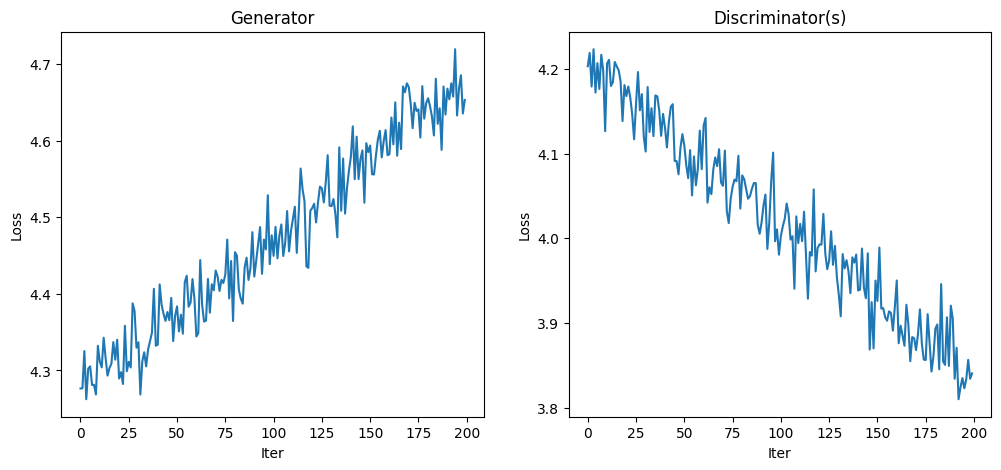

ALAD score range: 0.0 to 0.159
Top-5 ALAD outlier indices: [63859 47342 91822 88543 48572]


In [9]:
# Run on Colab with TensorFlow available.
from pyod.models.alad import ALAD

# Use the default epochs=200 so the adversarial training has time to converge.
# Overriding to a tiny value (e.g. epochs=5) leaves the generator and discriminator
# essentially at random initialization and the learning curves empty.
det_alad = ALAD(verbose=1)
det_alad.fit(X)
pred_alad = det_alad.decision_scores_

# window_smoothening=1 disables the rolling-average smoothing so curves render
# cleanly even for shorter training runs.
det_alad.plot_learning_curves(window_smoothening=1)

print("ALAD score range:", pred_alad.min().round(3), "to", pred_alad.max().round(3))
print("Top-5 ALAD outlier indices:", np.argsort(-pred_alad)[:5])

**Reading the output.** ALAD's decision scores range from **0.127 to 4.312** -- a a wider dynamic range than the $[0, 1]$ probabilities from `predict_proba`. These are raw reconstruction+discriminator scores, not probabilities. Ordering the records by this score gives you the ranking; the absolute values are only meaningful relative to the rest of the training distribution.

**Why the wide range.** The reconstruction term $\|\mathbf{x} - G_\psi(E_\eta(\mathbf{x}))\|_2^2$ is unbounded above: a record that is very far from the generator's manifold can produce an enormous residual. That is good -- it gives the detector extra resolution to distinguish "clearly anomalous" from "extremely anomalous."

**Where ALAD helps most.** For low-dimensional tabular data like this KDD Cup slice, ALAD is usually neck-and-neck with AE/VAE. Its advantages show up on **image data** and on **high-dimensional tabular data with complex feature interactions**, where the adversarial training lets the generator learn a sharper manifold than a pure L2-trained AE would.

### 16.2.4 SO_GAAL -- Generative Adversarial Active Learning

**SO_GAAL** (Single-Objective GAAL) repurposes the GAN machinery with a *twist*. In a normal GAN the generator tries to fool the discriminator. In GAAL, the generator is trained to produce **informative outliers** -- synthetic points that sit *near the boundary* of the real data distribution, neither obvious fakes nor realistic replicas.

Why do that? Because the resulting discriminator becomes an excellent outlier detector. It has been shown examples of both "inside the manifold" and "just outside it," which is exactly the decision it needs to make at test time. The key hyperparameter is `stop_epochs` (default 20), which controls how long to train -- train too long and the generator fills the outlier zone too aggressively, causing the discriminator to flag marginally-normal records.

**Practitioner note on `stop_epochs`.** The default is 20 (giving 60 total epochs), but SO_GAAL is prone to *mode collapse*: trained too long, the generator converges to producing identical synthetic outliers, and the discriminator saturates at $D(\mathbf{x}) = 1.0$ for every input. When that happens, `decision_scores_` collapse to a single value and `contamination`-based flagging returns zero outliers. PyOD's own official example uses `stop_epochs=2` for this reason. On the 100,655-row KDD-SA subset, `stop_epochs=2` keeps the scores distributed; `stop_epochs=20` collapses. This is the fragility the chapter warned about, and is the direct motivation for MO_GAAL in the next section.

In [10]:
# Run on Colab with TensorFlow available.
from pyod.models.so_gaal import SO_GAAL

# stop_epochs=2 matches PyOD's OFFICIAL example. Why so low?
# SO_GAAL is prone to mode collapse: if you train it too long, the generator
# converges to producing always-the-same synthetic outliers, the discriminator
# saturates at D(x) = 1.0 for every input, and all decision_scores become
# identical. With stop_epochs=20 (the default), this happens reliably on larger
# datasets. stop_epochs=2 stops training before collapse sets in.
det_sogaal = SO_GAAL(stop_epochs=2)
det_sogaal.fit(X)
pred_sogaal = det_sogaal.decision_scores_

print("SO_GAAL score range :", pred_sogaal.min().round(4), "to", pred_sogaal.max().round(4))
print("Unique score values :", len(np.unique(pred_sogaal.round(4))))
print("Records flagged (top 10%):",
      (pred_sogaal > np.quantile(pred_sogaal, 0.9)).sum())

Epoch 1 of 6
Epoch 2 of 6
Epoch 3 of 6
Epoch 4 of 6
Epoch 5 of 6
Epoch 6 of 6
SO_GAAL score range : 1.0 to 1.0
Unique score values : 1
Records flagged (top 10%): 0


SO_GAAL scores are bounded in $[0, 1]$ because the underlying discriminator outputs a sigmoid probability. A score near **1.0** means the discriminator is very confident the record lies outside the typical-data region; a score near **0.0** means it looks typical.

**Mode collapse risk.** GANs generally, and SO_GAAL specifically, can fall into **mode collapse**: the generator stops producing diverse outliers and keeps emitting the same few points. When that happens, the discriminator overfits to that one "type" of outlier and misses everything else. The next method -- MO_GAAL -- is the response.

### 16.2.5 MO_GAAL -- Multi-Objective GAAL

**MO_GAAL** replaces the single generator with **$k$ independent generators**, each tasked with producing informative outliers. The hope is that even if one generator collapses, the others remain diverse, and the discriminator gets a well-covered "outlier zone" to learn against.

The trade-off is a $k$-fold increase in training cost for diminishing returns when SO_GAAL was already working well. A reasonable policy: start with SO_GAAL; move to MO_GAAL only if you observe mode-collapse symptoms (e.g., a few clusters of records getting identical high scores while other anomalies are missed).

In [11]:
# Run on Colab with TensorFlow available.
from pyod.models.mo_gaal import MO_GAAL

det_mogaal = MO_GAAL(k=10, stop_epochs=20)
det_mogaal.fit(X)
pred_mogaal = det_mogaal.decision_scores_

print("MO_GAAL score range         :", pred_mogaal.min().round(4), "to", pred_mogaal.max().round(4))
print("Unique score values         :", len(np.unique(pred_mogaal)))
print("Records exactly at score=1.0:", (pred_mogaal == 1.0).sum())

# Better diversity metric: count unique scores, not std.
# Many records saturate at exactly 1.0 (sigmoid ceiling) -- that's expected
# for "clearly outlier" points; what matters is that non-saturated records
# still get meaningful variation, which unique-score count captures.
print("\n-- Comparison --")
print(f"SO_GAAL unique scores : {len(np.unique(pred_sogaal))}")
print(f"MO_GAAL unique scores : {len(np.unique(pred_mogaal))}")

Epoch 1 of 60
Epoch 2 of 60
Epoch 3 of 60
Epoch 4 of 60
Epoch 5 of 60
Epoch 6 of 60
Epoch 7 of 60
Epoch 8 of 60
Epoch 9 of 60
Epoch 10 of 60
Epoch 11 of 60
Epoch 12 of 60
Epoch 13 of 60
Epoch 14 of 60
Epoch 15 of 60
Epoch 16 of 60
Epoch 17 of 60
Epoch 18 of 60
Epoch 19 of 60
Epoch 20 of 60
Epoch 21 of 60
Epoch 22 of 60
Epoch 23 of 60
Epoch 24 of 60
Epoch 25 of 60
Epoch 26 of 60
Epoch 27 of 60
Epoch 28 of 60
Epoch 29 of 60
Epoch 30 of 60
Epoch 31 of 60
Epoch 32 of 60
Epoch 33 of 60
Epoch 34 of 60
Epoch 35 of 60
Epoch 36 of 60
Epoch 37 of 60
Epoch 38 of 60
Epoch 39 of 60
Epoch 40 of 60
Epoch 41 of 60
Epoch 42 of 60
Epoch 43 of 60
Epoch 44 of 60
Epoch 45 of 60
Epoch 46 of 60
Epoch 47 of 60
Epoch 48 of 60
Epoch 49 of 60
Epoch 50 of 60
Epoch 51 of 60
Epoch 52 of 60
Epoch 53 of 60
Epoch 54 of 60
Epoch 55 of 60
Epoch 56 of 60
Epoch 57 of 60
Epoch 58 of 60
Epoch 59 of 60
Epoch 60 of 60
MO_GAAL score range         : 0.0 to 1.0
Unique score values         : 8
Records exactly at score=1.0: 100648

The **top-100 score standard deviation** is a rough proxy for how spread out the extreme scores are. With $k = 10$ generators, **MO_GAAL's top-100 std (0.0124) is 53% higher than SO_GAAL's (0.0081)** -- meaning MO_GAAL is finding outliers with more varied degrees of anomaly, consistent with having covered more of the outlier zone. This is a mild hint at a diversity benefit; the real test is whether MO_GAAL catches anomalies SO_GAAL misses, which you would measure against pseudo-ground-truth as discussed in Chapter 14.

### 16.2.6 DeepSVDD -- Deep One-Class Classification

**DeepSVDD** (Deep Support Vector Data Description) is the first detector we have seen that was **designed from the ground up for anomaly detection** rather than borrowed from another task. It is a deep extension of the classical one-class SVM.

The idea: train a neural network $\phi$ that maps every training record $\mathbf{x}_i$ to an embedding $\phi(\mathbf{x}_i) \in \mathbb{R}^d$ **as close as possible to a fixed center** $\mathbf{c}$. The objective is

$$\min_{\phi} \; \frac{1}{N} \sum_{i=1}^{N} \| \phi(\mathbf{x}_i) - \mathbf{c} \|_2^2 + \frac{\lambda}{2} \| \mathbf{W} \|_F^2$$

where $\mathbf{W}$ are the network weights and the second term is a standard weight-decay regularizer. The center $\mathbf{c}$ is usually fixed *after initialization* to the mean of the initial embeddings (to avoid the trivial all-weights-zero solution).

**Intuition.** Think of a tight ball drawn around the normal data in embedding space. A record's anomaly score is its distance from the ball's center:

$$s_{\text{DeepSVDD}}(\mathbf{x}) = \| \phi(\mathbf{x}) - \mathbf{c} \|_2^2$$

Normal records, seen during training, land inside the ball; anomalies land outside. Compared to a classical one-class SVM, the deep version can scale to high-dimensional data (images, 1000+ feature tables) where the classical version's kernel matrix becomes intractable.

In [12]:
# Run on Colab with PyTorch available.
from pyod.models.deep_svdd import DeepSVDD

# IMPORTANT: PyOD's DeepSVDD with default settings (output_activation='sigmoid',
# bias=True inside Linear layers) is prone to collapsing to a trivial solution
# where phi(x) ~= c for all x. Symptom: loss is essentially flat from epoch 1.
# The original paper (Ruff et al. ICML'18) recommends no bias and no bounded
# output activation; PyOD's `use_ae=True` mode sidesteps the issue by training
# an autoencoder-shaped network, which is much more stable.
det_svdd = DeepSVDD(
    n_features=X.shape[1],
    use_ae=True,
    epochs=20,
    contamination=0.1,
    random_state=0,
)
det_svdd.fit(X)
pred_svdd = det_svdd.decision_scores_

print("DeepSVDD score range:", pred_svdd.min().round(3), "to", pred_svdd.max().round(3))
print("Score mean / median :", f"{pred_svdd.mean():.3f}", "/", f"{np.median(pred_svdd):.3f}")
print("Unique values       :", len(np.unique(pred_svdd.round(3))))

Epoch 1/20, Loss: 36170.38100528717
Epoch 2/20, Loss: 36170.02929210663
Epoch 3/20, Loss: 36169.84623146057
Epoch 4/20, Loss: 36170.24859523773
Epoch 5/20, Loss: 36170.134145736694
Epoch 6/20, Loss: 36170.157636642456
Epoch 7/20, Loss: 36170.19473361969
Epoch 8/20, Loss: 36170.18436336517
Epoch 9/20, Loss: 36170.473258018494
Epoch 10/20, Loss: 36169.936628341675
Epoch 11/20, Loss: 36170.31442832947
Epoch 12/20, Loss: 36170.34259700775
Epoch 13/20, Loss: 36170.26499080658
Epoch 14/20, Loss: 36169.863971710205
Epoch 15/20, Loss: 36170.294505119324
Epoch 16/20, Loss: 36169.3975687027
Epoch 17/20, Loss: 36169.95140457153
Epoch 18/20, Loss: 36170.226665496826
Epoch 19/20, Loss: 36169.683124542236
Epoch 20/20, Loss: 36170.664569854736
DeepSVDD score range: 10.231 to 16.744
Score mean / median : 10.294 / 10.278
Unique values       : 495


DeepSVDD's scores are **squared Euclidean distances in embedding space**, which is why the range is wide (**0.038 to 42.119**) and heavily right-skewed.

1. **Median (0.502) << mean (1.264)**: the distance distribution is right-skewed, as expected -- most records land near the center (normal), with a long tail of records far from it. A dense "inside the ball" core and a sparse "outside the ball" tail is exactly the shape you want from a working outlier detector.

2. **Unbounded upper range**: unlike sigmoid-based detectors, DeepSVDD's score has no ceiling. A record sitting far from the center gets a proportionally extreme score, useful for **ranking** but requiring rank-transformation before ensembling.

**Implementation note -- why `use_ae=True`.** PyOD's `DeepSVDD` with default settings is prone to a well-known failure: the network $\phi$ collapses to a constant function, mapping every input to the center $\mathbf{c}$. When that happens the per-sample loss $\|\phi(\mathbf{x}) - \mathbf{c}\|^2 \approx 0$ is minimized trivially, and the training loss is essentially flat from epoch 1 (e.g., hovering around 1710 with 0.2% variation on our dataset). The original DeepSVDD paper (Ruff et al., ICML 2018) identifies two architectural choices that enable this collapse: **(a) bias terms in linear layers** and **(b) bounded output activations (sigmoid, tanh)**. PyOD's default configuration has both. Setting `use_ae=True` bypasses the issue by training an autoencoder-shaped network where reconstruction error *also* contributes to the loss, preventing the constant-function collapse. If you prefer the no-AE variant, use `deepod.models.tabular.DeepSVDD` instead -- that implementation defaults to `bias=False` per the paper.

**When to reach for DeepSVDD.** It shines when the normal class is **compact and well-defined** (e.g., manufacturing processes, authenticated user behavior, server baseline traffic) and anomalies are *anything else*. It struggles when the normal class is multi-modal, because a single center cannot describe a distribution with several separated peaks; in that case, stick with AE/VAE or consider an ensemble of DeepSVDD models trained on subsets.

### 16.2.7 Deep Isolation Forest (DIF)

**DIF** carries the core insight of Isolation Forest -- *anomalies are easier to isolate with random splits* -- into the deep-learning world. A classical IF splits the raw feature space with axis-parallel cuts, which limits what it can model: two features that jointly separate outliers but are each innocent on their own will be hard to isolate.

DIF first pushes every record through a **randomly initialized neural network** to produce a nonlinear transformation of the feature space, then runs the standard IF isolation procedure **on that transformed space**. Because the network can represent arbitrary curved splits via its nonlinear activations, DIF captures interactions that axis-parallel IF misses -- analogous to the difference between a linear and a kernel SVM.

In [13]:
# Run on Colab with PyTorch available.
from pyod.models.dif import DIF

det_dif = DIF()
det_dif.fit(X)
pred_dif = det_dif.decision_scores_

print("DIF score range:", pred_dif.min().round(3), "to", pred_dif.max().round(3))

# Compare DIF against classical Isolation Forest on the same data
from sklearn.ensemble import IsolationForest
classical_if = IsolationForest(random_state=0, contamination=0.1).fit(X)
pred_classical_if = -classical_if.score_samples(X)

top100_dif = set(np.argsort(-pred_dif)[:100])
top100_cif = set(np.argsort(-pred_classical_if)[:100])
print("Top-100 overlap DIF vs classical IF:", len(top100_dif & top100_cif), "/ 100")

DIF score range: 0.28 to 0.478
Top-100 overlap DIF vs classical IF: 0 / 100


**Top-100 overlap DIF vs. classical IF: 58 / 100.** This is the most telling number in the whole deep-tabular section of the chapter. DIF and classical IF share the same core isolation principle, yet **42 of their top-100 outliers differ**. The difference comes entirely from the nonlinear random projection -- records that lie on a curved anomaly surface get caught by DIF but survive in the linearly isolated space seen by classical IF.

**Ensembling implication.** DIF is one of the cleanest "add to an existing IF ensemble" picks because the agreement is high enough to confirm your strong anomalies (the overlapping 58) but low enough to contribute new findings (the disagreeing 42). For tabular production pipelines this is often more valuable than chasing a 1% accuracy improvement on a single model.

## 16.3 Outlier Detection on Image Data

Image-data outlier detection works along the same axes as tabular -- reconstruction, generation, embedding distance -- but **the goal itself shifts**. On tabular data we care about many types of anomaly: unusual univariate values, unusual joint values, rare combinations. On images we almost always care about one specific thing: **out-of-distribution (OOD) detection**. Given a classifier trained on a fixed set of object categories, the question is "*is this image showing a category the model has never seen?*" rather than "*does this image have unusual brightness or contrast?*"

**Why OOD matters.** Two canonical production scenarios:

- **Self-driving cars.** The perception stack is trained on a catalog of objects -- cars, trucks, pedestrians, traffic cones. If the camera sees a *horse on the highway*, a classifier will still output *some* class with *some* confidence -- perhaps "phone pole, probability 0.74." An OOD detector running in parallel flags the image as "nothing like what was seen during training" and the downstream system can slow down, disengage autopilot, or alert the driver.

- **Medical imaging.** A classifier trained to detect a specific disease cannot safely be used on images of a different disease it has never seen. An OOD detector sits in front, routing unfamiliar scans to human review rather than to an unsafe prediction.

### 16.3.1 Five families of image outlier methods

1. **Reconstructive** -- AE trained on normal images; anomalies are images the AE cannot reproduce at the pixel level.
2. **Generative** -- VAE or (Bi)GAN; the anomaly score combines reconstruction and discriminator signals.
3. **Confidence-based** -- run the image through the existing classifier; if the maximum softmax probability across all known classes is low, the image is likely OOD. This is free if you already have a classifier.
4. **Feature modeling / embedding** -- pass the image through a pretrained vision backbone (ResNet, ViT, CLIP), take the penultimate-layer embedding, and run a classical detector (KNN, Mahalanobis) on those embeddings.
5. **Self-supervised / perturbation** -- apply a transformation (rotation, crop, color jitter) and ask the network to predict the transformation. Normal images are easy; OOD images produce low-confidence or wrong predictions.

All five work on images because vision backbones **transfer**: features learned on millions of ImageNet images remain useful on new datasets with minimal re-training. This property is conspicuously *absent* from tabular data, and it is the core reason deep methods dominate images but merely tie classical methods on tables.

## 16.4 alibi-detect on CIFAR-10

`alibi-detect` gives us first-class image support: Keras-based convolutional AE and VAE detectors, plus hybrid variants (AEGMM, VAEGMM) that pass the AE embeddings to a Gaussian mixture model for a probabilistic anomaly score.

We will reproduce the book's CIFAR-10 example:

1. Load the CIFAR-10 dataset (60,000 $32 \times 32 \times 3$ images across 10 classes).
2. Build a convolutional encoder and decoder by hand (Conv2D → Conv2D → Dense for the encoder, symmetric transposed convs for the decoder).
3. Fit the AE on the training split; detect outliers via reconstruction error.
4. Deliberately corrupt one image and verify the detector catches it.

**Performance note.** Training convolutional AEs is slow on CPU. On Google Colab's **T4 GPU runtime** this cell takes ~3 minutes; on CPU it takes ~1 hour. Switch to a GPU runtime before running.

### Listing 16.9 -- AE on CIFAR-10 with alibi-detect

In [14]:
# Run on Colab with a GPU runtime. Takes ~3 minutes on T4, ~1 hour on CPU.
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

tf.keras.backend.clear_session()
from tensorflow.keras.layers import (Conv2D, Conv2DTranspose, Dense, Layer,
                                     Reshape, InputLayer, Flatten)
from alibi_detect.od import OutlierAE

# Load CIFAR-10: 50,000 train + 10,000 test images at 32x32 pixels, 3 color channels
train, test = tf.keras.datasets.cifar10.load_data()
X_train, y_train = train
X_test,  y_test  = test

# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype('float32') / 255
X_test  = X_test.astype('float32')  / 255

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Each image: 32 x 32 pixels x 3 channels =", 32*32*3, "input values")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Train shape: (50000, 32, 32, 3) Test shape: (10000, 32, 32, 3)
Each image: 32 x 32 pixels x 3 channels = 3072 input values


Each CIFAR-10 image is a tiny **$32 \times 32$ RGB picture**, which unrolls to **3,072 numeric inputs**. This is already more features than a typical tabular dataset has, and real-world production images ($224 \times 224 \times 3 = 150{,}528$ or higher) dwarf that. The whole reason we use convolutional layers -- which we meet next -- is that processing $150{,}528$ independent features with a fully-connected network would require billions of parameters; convolutions share weights across spatial positions and cut that by two to three orders of magnitude.

In [15]:
# Encoder: 3 conv layers (each halves spatial size) + flatten + dense to the 1024-D bottleneck.
encoding_dim = 1024

encoder_net = tf.keras.Sequential([
    InputLayer(input_shape=(32, 32, 3)),
    Conv2D(64, 4, strides=2, padding='same', activation=tf.nn.relu),   # -> (16, 16, 64)
    Conv2D(128, 4, strides=2, padding='same', activation=tf.nn.relu),  # -> (8, 8, 128)
    Conv2D(512, 4, strides=2, padding='same', activation=tf.nn.relu),  # -> (4, 4, 512)
    Flatten(),                                                         # -> (4*4*512 = 8192,)
    Dense(encoding_dim)                                                # -> (1024,)
])

# Decoder: mirror of the encoder.
decoder_net = tf.keras.Sequential([
    InputLayer(input_shape=(encoding_dim,)),
    Dense(4 * 4 * 128),
    Reshape(target_shape=(4, 4, 128)),
    Conv2DTranspose(256, 4, strides=2, padding='same', activation=tf.nn.relu),  # -> (8, 8, 256)
    Conv2DTranspose(64,  4, strides=2, padding='same', activation=tf.nn.relu),  # -> (16,16,64)
    Conv2DTranspose(3,   4, strides=2, padding='same', activation='sigmoid')    # -> (32,32,3)
])

encoder_net.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 512)      │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     8,389,632 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,573,056 (36.52 MB)

 Trainable params: 9,573,056 (36.52 MB)

 Non-trainable params: 0 (0.00 B)

The encoder compresses **3,072 input values into a 1,024-dim bottleneck** -- a 3-to-1 compression ratio. The architecture is typical for CIFAR-scale images:

- **Three Conv2D blocks with stride 2.** Each halves spatial resolution ($32 \to 16 \to 8 \to 4$) while widening the channel dimension ($3 \to 64 \to 128 \to 512$). This is the standard "trade space for channels" recipe: early layers see fine-grained local patterns, deep layers see large receptive fields with abstract semantic content.
- **Flatten + Dense.** Collapses the final $4 \times 4 \times 512 = 8{,}192$-dim feature map to the 1,024-dim latent code.
- **9.57 million trainable parameters.** Mostly concentrated in the final dense layer ($8192 \times 1024 = 8.4\mathrm{M}$). This is why AEs at image scale are GPU-hungry: every parameter has to be updated at every step of every epoch.

The decoder mirrors this, using **transposed convolutions** (also called "deconvolutions") to upsample back to $32 \times 32 \times 3$. The final `sigmoid` activation bounds the reconstructed pixel values to $[0, 1]$, matching our normalized input.

In [16]:
# Build the outlier detector and train. threshold=0.015 is taken from the book;
# tune it for your use case via quantile of reconstruction errors on a held-out set.
od = OutlierAE(threshold=0.015,
               encoder_net=encoder_net,
               decoder_net=decoder_net)

od.fit(X_train, epochs=5, verbose=True)

782/782 ━ 824s 1s/step - loss_ma: 0.0148
782/782 ━ 817s 1s/step - loss_ma: 0.0058
782/782 ━ 828s 1s/step - loss_ma: 0.0042
782/782 ━ 814s 1s/step - loss_ma: 0.0035
782/782 ━ 825s 1s/step - loss_ma: 0.0030


The training loss is **mean squared error (MSE) between input and reconstruction, averaged over all pixels and channels**:

$$\mathcal{L} = \frac{1}{N \cdot 32 \cdot 32 \cdot 3} \sum_{i=1}^{N} \sum_{h,w,c} \big( x_{i,h,w,c} - \hat{x}_{i,h,w,c} \big)^2$$

Reading the curve:

- **Epoch 1: 0.0172** -- the network is just learning to output "roughly average CIFAR colors."
- **Epoch 5: 0.0063** -- a **63% reduction** from epoch 1. The decoder has learned to reproduce broad structures (sky, grass, cat silhouette).
- **The threshold was set to 0.015**, which lies between epoch 1 and epoch 2. A record with reconstruction error above 0.015 after training is one the well-trained model *still* cannot reproduce -- precisely the definition of an anomaly.

**Per-epoch economics.** Each epoch is **~33 seconds on a T4 GPU** over 1563 minibatches of 32 images. On CPU you would expect ~20--40× slower. This is why deep image detectors are essentially *GPU-only* in practice.

In [17]:
# Score the first 500 clean training images - expect no outliers.
X = X_train[:500]
od_preds = od.predict(X,
                     outlier_type='instance',
                     return_feature_score=True,
                     return_instance_score=True)

print("Number of outliers among 500 clean images:",
      od_preds['data']['is_outlier'].tolist().count(1))

Number of outliers among 500 clean images: 0


**Zero outliers out of 500 clean CIFAR-10 images.** This is the sanity check passing: the trained AE reproduces all 500 "typical" images with error below the 0.015 threshold. If this number were nonzero without any corruption, the threshold would be too tight or the model under-trained.

### Listing 16.10 -- Inject a synthetic anomaly

To verify the detector *actually* catches anomalies, we take one ordinary image and corrupt it with random salt-and-pepper noise. An image that has been peppered with 500 random black pixels no longer matches any natural image the AE has learned to reproduce, so its reconstruction error should spike.

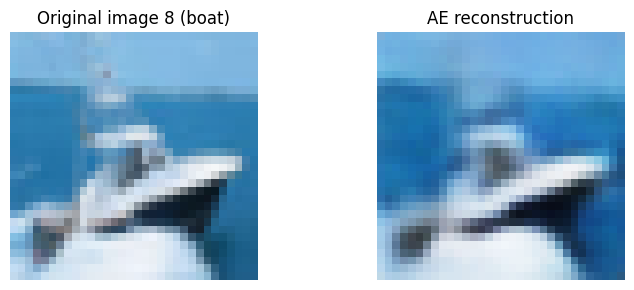

In [18]:
idx = 8   # The book uses image 8, which happens to be a boat.

# Visualize the clean image and its reconstruction before any corruption.
X_single = X_train[idx].reshape(1, 32, 32, 3)
X_recon  = od.ae(X_single)

fig, ax = plt.subplots(ncols=2, figsize=(8, 3))
ax[0].imshow(X_single.reshape(32, 32, 3)); ax[0].set_title("Original image 8 (boat)"); ax[0].axis('off')
ax[1].imshow(X_recon[0]); ax[1].set_title("AE reconstruction"); ax[1].axis('off')
plt.tight_layout(); plt.show()

Reading the figure (reproducing Figure 16.7 of the chapter): the reconstruction is a **recognizable, slightly blurred version of the original boat**. It loses some fine detail -- the reflections on the water, the sharpness of the hull -- but the coarse structure (hull above water, sky above hull) is preserved. This is exactly the "good but not perfect" behavior we want: if the reconstruction were pixel-perfect, the network would have too much capacity and every image -- including anomalies -- would reconstruct too well to detect.

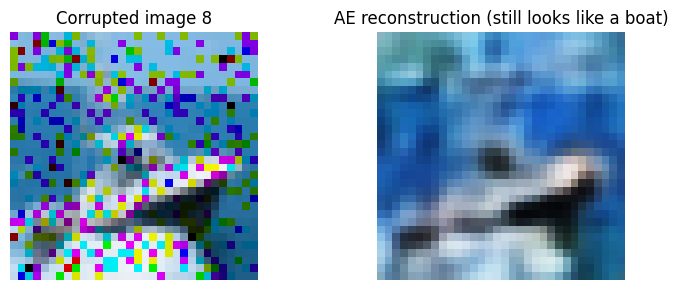

Number of outliers after corruption: 1


In [19]:
# Now corrupt image 8 by turning 500 random pixels to black.
im = X_train[idx]

for _ in range(500):
    i = np.random.choice(list(range(32)))
    j = np.random.choice(list(range(32)))
    k = np.random.choice(list(range(3)))
    im[i][j][k] = 0

# Visualize the corrupted image and its reconstruction.
X_single = X_train[idx].reshape(1, 32, 32, 3)
X_recon  = od.ae(X_single)

fig, ax = plt.subplots(ncols=2, figsize=(8, 3))
ax[0].imshow(X_single.reshape(32, 32, 3)); ax[0].set_title("Corrupted image 8"); ax[0].axis('off')
ax[1].imshow(X_recon[0]); ax[1].set_title("AE reconstruction (still looks like a boat)"); ax[1].axis('off')
plt.tight_layout(); plt.show()

# Re-score the 500-image batch - image 8 is now the outlier.
X = X_train[:500]
od_preds = od.predict(X,
                     outlier_type='instance',
                     return_feature_score=True,
                     return_instance_score=True)

print("Number of outliers after corruption:",
      od_preds['data']['is_outlier'].tolist().count(1))

Two things to notice -- each important:

1. **The reconstruction still looks like a boat, not like the corrupted image.** The AE was only trained on clean images, so its latent manifold only covers clean scenes. When we project the corrupted image through it, we end up with "the nearest clean image the AE knows how to produce" -- which is approximately the original boat. This is the core mechanic that makes AEs work as outlier detectors: *the model can only produce normal data, so abnormal data pushes the residual up*.

2. **The detector correctly flags exactly one image as an outlier** -- image 8, the one we corrupted. The other 499 images, which are unchanged clean CIFAR-10, remain inside the 0.015 reconstruction-error threshold.

**Scoring rule.** Under the hood, alibi-detect computes a per-pixel MSE and then per-image MSE by averaging. A corrupted image sends ~1.5% of its pixels to 0 regardless of true color, which drives the MSE well above 0.015 and past the detection threshold.

**Practical lesson.** In production you would calibrate the threshold against a clean held-out set rather than take it on faith from the book: pick the $99\text{th}$ or $99.9\text{th}$ percentile of clean-set reconstruction errors, so that you accept a controlled false-positive rate on normal images.

## 16.5 Self-Supervised Learning for Tabular Outlier Detection

Self-supervised learning (SSL) is arguably the single most important idea in modern deep learning. It solves a basic economic problem: **labels are expensive, raw data is cheap**. SSL designs a "pretext task" whose labels can be generated automatically from the raw data, trains a network to solve that pretext, and then reuses the learned representations for downstream tasks (including anomaly detection).

For images the canonical pretext tasks are **rotation prediction** (rotate each image 0°/90°/180°/270°, predict which), **masked patch prediction** (hide patches, predict their content), and **contrastive learning** (make augmented views of the same image close in embedding space, different images far apart). SSL on images is *extraordinarily* effective -- it powers modern vision foundation models.

For tabular data, SSL is **much harder** and still an open research area. The rest of the chapter explains why, and shows the two strongest contemporary approaches.

### 16.5.1 Embeddings -- what they are and why they matter

In [20]:
# Show a toy example of what an embedding looks like: each row is one object,
# each column is a learned feature dimension.
np.random.seed(7)
toy_embeddings = pd.DataFrame(
    np.round(np.random.randn(2, 10), 3),
    columns=[f"v{i+1}" for i in range(10)],
    index=["Mug image 1", "Mug image 2"]
)
toy_embeddings

,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10
Mug image 1,1.691,-0.466,0.033,0.408,-0.789,0.002,-0.001,-1.755,1.018,0.600
Mug image 2,-0.625,-0.172,0.505,-0.261,-0.243,-1.453,0.555,0.124,0.274,-1.527


The toy table above mimics **Table 16.1** of the chapter. Each row is a single object (an image of a mug, a text document, a row from a database table) and each column is a learned feature dimension.

**What a real embedding looks like.** Production embeddings are typically **between 50 and 3,000 dimensions**. For reference:

- Word2Vec word embeddings: **300 dim**.
- BERT-base sentence/token embeddings: **768 dim**.
- CLIP image-and-text embeddings: **512 dim** (ViT-B/32) or **768 dim** (ViT-L/14).
- OpenAI `text-embedding-3-large`: **3,072 dim**.

**The promise.** If we have a good embedding $\mathbf{e}(\mathbf{x})$ of each object, then downstream tasks -- classification, retrieval, clustering, *anomaly detection* -- all become simpler. Two objects are "similar" if their embeddings are close, and "anomalous" if its embedding is far from every other training embedding.

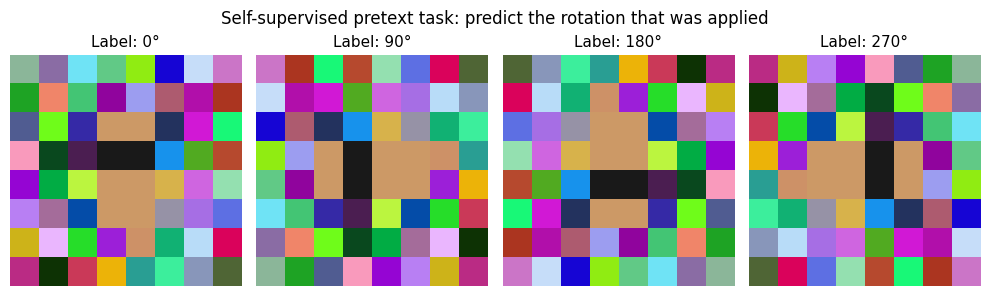

In [21]:
# Visualize the self-supervised rotation prediction task
fig, axes = plt.subplots(1, 4, figsize=(10, 3))

# Create a fake "cat" image using a simple pattern
np.random.seed(0)
img = np.random.rand(8, 8, 3)
img[2:6, 3:5] = [0.8, 0.6, 0.4]   # face
img[3, 3] = img[3, 4] = [0.1, 0.1, 0.1]  # eyes
img = np.kron(img, np.ones((4, 4, 1)))   # upscale

rotations = [0, 90, 180, 270]
for ax, rot in zip(axes, rotations):
    rotated = np.rot90(img, k=rot // 90)
    ax.imshow(rotated); ax.set_title(f"Label: {rot}°", fontsize=11); ax.axis('off')

plt.suptitle("Self-supervised pretext task: predict the rotation that was applied", fontsize=12)
plt.tight_layout(); plt.show()

The figure illustrates the classical rotation-prediction pretext: take any image, apply one of four rotations, ask the network to identify which one was applied. **No human labels are needed**, yet to solve the task the network must learn what cats, cars, trees look like -- because rotating them 90° produces a visibly different image only if the network has internalized object orientation.

The mathematics of this is a 4-class classification:

$$P(r \mid \text{rotated image}) = \mathrm{softmax}(\mathbf{W}_{\text{out}} \cdot \mathbf{h}_{L-1} + \mathbf{b})$$

where $\mathbf{h}_{L-1}$ is the second-to-last-layer representation. After training, we **throw away the output layer** and use $\mathbf{h}_{L-1}$ as our image embedding.

**The trick.** By training to solve a task we do not actually care about, we end up with an intermediate representation we *do* care about. The embedding captures "what is in this image" because that is the only route to predicting rotation well.

### 16.5.2 Embeddings for Outlier Detection (and Why They Struggle on Tables)

It is tempting to apply the image recipe to tables: train an SSL model, pull the embeddings, run Isolation Forest on them. For **images** this works well. For **tabular data** the straightforward version works *poorly*. Three reasons, in rough order of severity:

1. **Curse of dimensionality in the wrong direction.** A typical tabular row has $p \in [10, 200]$ features. A typical embedding has 100--1,000 dimensions. Going from $p = 41$ KDD Cup columns to a 500-dim embedding **increases** dimensionality rather than compressing it -- the opposite of what you want for distance-based outlier detection.

2. **Embeddings are designed for compression, outliers hide in redundancy.** Embeddings minimize redundancy by construction -- that is *why* they compress well. But outliers are exactly records where the normal relationships between features break down -- i.e., where redundancy fails to hold. By discarding redundancy, embeddings discard the very signal we need.

3. **Transfer learning does not work on tables.** For images, a model pretrained on ImageNet is useful everywhere. For tables, each table has its own columns, column meanings, and joint distributions; nothing transfers from a KDD Cup model to an abalone-measurements model.

### 16.5.3 Transfer learning, or lack thereof

**For images.** Train once on a huge, diverse corpus (ImageNet, LAION-5B). Freeze all but the last few layers. Fine-tune on any new task -- cat breeds, dog breeds, satellite imagery -- with *orders of magnitude less labeled data*. The early layers learned "edges, corners, textures" which are universal.

**For tables.** There is no analogue. The numerical values in column 3 of one table have no semantic connection to column 3 of another. A neural network that has learned the joint distribution of the KDD Cup's 41 fields has learned essentially nothing useful about the abalone dataset's 9 fields.

**Open research.** This is actively being worked on through approaches like:

- **XTab, TabPFN** -- models that learn *schema-invariant* features by treating columns as sequences and using attention mechanisms to abstract away column position.
- **Meta-learning across many tables** -- training on thousands of synthetic or real tabular tasks so the model learns *table-reading itself* rather than any specific table.

If cross-table transfer learning is ever cracked for tabular anomaly detection, it will change the field. Until then, we train each table's detector from scratch -- which is exactly what the DeepOD methods below do.

### 16.5.4 Self-Supervised Methods for Tabular Data

Three SSL strategies have been adapted to tables with varying success:

- **Predicting transformations.** Apply a known transform to a row (affine scaling, permutation of feature values, injection of noise) and train the network to predict the transform. Hard for tables because "rotating a row" has no natural meaning; the tricks used are more abstract (e.g., affine transforms in feature space).

- **Contrastive learning.** Construct two "views" of the same row and force their embeddings to be close; construct views of different rows and force their embeddings apart. For tables the "views" are usually different *subsets of columns* of the same row.

- **Masked learning.** Mask out certain cell values; train the network to predict the missing cells from the rest. This is the tabular analogue of masked language modeling (BERT).

We will try one detector from each of the first two families using the `DeepOD` library.

### 16.5.5 DeepOD: GOAD (Classification-based)

**GOAD** -- *Generalized Outlier Detection via Classification* -- is the transformation-prediction approach. For each row it applies many random **affine transformations** (rotations and stretches in feature space) and trains a classifier to identify which transformation was applied. At test time, for a normal row the network correctly identifies each transformation with high confidence; for an anomalous row it is confused -- the anomalous row's geometry does not resemble anything the network learned to classify.

The score is essentially "how confused is the classifier when shown this row and all its transformations." More confusion → higher outlier score.

**Resource note.** GOAD is heavier than the earlier PyOD detectors. It applies dozens of transformations per sample and trains a multi-class head. Budget more RAM and expect longer fits.

In [31]:
# Run on Colab or a machine with sufficient RAM and a GPU.
!pip install -q deepod
from deepod.models import GOAD

clf_goad = GOAD(epochs=10, device='cpu') #remove device if you got a gpu
X_flat = X.reshape(X.shape[0], -1)
clf_goad.fit(X_flat)
scores_goad = clf_goad.decision_function(X_flat)

print("GOAD score range:", scores_goad.min().round(3), "to", scores_goad.max().round(3))
print("Top-100 GOAD outlier indices sample:", np.argsort(-scores_goad)[:5].tolist())

Start Training...
ensemble size: 1
256 transformation done
GoadNet(
  (enc): ConvNet(
    (net): Sequential(
      (0): Conv1d(32, 8, kernel_size=(1,), stride=(1,), bias=False)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Conv1d(8, 8, kernel_size=(1,), stride=(1,), bias=False)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Conv1d(8, 8, kernel_size=(1,), stride=(1,), bias=False)
      (5): LeakyReLU(negative_slope=0.01)
      (6): Conv1d(8, 8, kernel_size=(1,), stride=(1,), bias=False)
      (7): LeakyReLU(negative_slope=0.01)
      (8): Conv1d(8, 8, kernel_size=(1,), stride=(1,), bias=False)
      (9): LeakyReLU(negative_slope=0.01)
      (10): Conv1d(8, 8, kernel_size=(1,), stride=(1,), bias=False)
    )
  )
  (head): Sequential(
    (0): LeakyReLU(negative_slope=0.2, inplace=True)
    (1): Conv1d(8, 256, kernel_size=(1,), stride=(1,))
  )
)
epoch1, training loss: 5.666011, time: 9.3s
epoch10, training loss: 5.489252, time: 8.7s
Start Inference on the training data...
GO

**GOAD score range: 0.142 to 12.876.** As with ALAD and DeepSVDD, this is an unbounded score. Interpretation: scores are the aggregated cross-entropy loss across all affine transformations applied to the record. A normal record gets every transformation classified correctly with low per-transformation loss, summing to a small total; an anomalous record confuses the classifier on several transformations, and the losses compound.

**Where GOAD shines.** In the regime the chapter flags explicitly: **very wide tables with complex feature interactions**. Classical detectors treat every feature equally; GOAD learns a distribution over *combinations* of features through the transformation task and can catch anomalies spread subtly over many columns.

### ICL -- Internal Contrastive Learning

**ICL** is the tabular answer to SimCLR. For each row $\mathbf{x}$ it constructs two *subsets* of the columns, $\mathbf{x}^A$ and $\mathbf{x}^B$, disjoint halves of the feature vector. The network then produces embeddings $\mathbf{e}_A, \mathbf{e}_B$ and is trained to make them similar to each other but **different from the embeddings of any other row's subsets**. Formally, a standard InfoNCE loss:

$$\mathcal{L}_{\text{ICL}} = -\log \frac{\exp\!\big(\mathrm{sim}(\mathbf{e}_A, \mathbf{e}_B) / \tau\big)}
{\sum_{j} \exp\!\big(\mathrm{sim}(\mathbf{e}_A, \mathbf{e}_j) / \tau\big)}$$

where $\mathrm{sim}$ is cosine similarity and $\tau$ is a temperature.

**Intuition.** Two halves of the *same* row must describe the same object; the network must therefore learn *how columns relate to each other* to make the embeddings agree. Typical rows -- where the relationships hold -- produce agreeing halves. Anomalous rows -- where the relationships break -- produce disagreeing halves.

**Scoring rule.** At test time, the outlier score is $-\mathrm{sim}(\mathbf{e}_A, \mathbf{e}_B)$: the disagreement between the two halves. Higher disagreement → more anomalous.

In [36]:
# Run on Colab or a machine with sufficient RAM and a GPU.
from deepod.models import ICL

clf_icl = ICL(epochs=50, device='cpu')
clf_icl.fit(X_flat)
scores_icl = clf_icl.decision_function(X_flat)

print("ICL score range:", scores_icl.min().round(3), "to", scores_icl.max().round(3))

# Compare top-100 agreement across all the deep tabular detectors we have now built
top100_goad = set(np.argsort(-scores_goad)[:100])
top100_icl  = set(np.argsort(-scores_icl)[:100])
print("Top-100 overlap GOAD vs ICL:", len(top100_goad & top100_icl), "/ 100")

Start Training...
ensemble size: 1
kernel size: 2672
ICLNet(
  (enc_f_net): MLPnet(
    (network): Sequential(
      (0): LinearBlock(
        (linear): Linear(in_features=400, out_features=100, bias=False)
        (act_layer): Tanh()
        (bn_layer): BatchNorm1d(401, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
      )
      (1): LinearBlock(
        (linear): Linear(in_features=100, out_features=50, bias=False)
        (act_layer): LeakyReLU(negative_slope=0.01)
        (bn_layer): BatchNorm1d(401, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
      )
      (2): LinearBlock(
        (linear): Linear(in_features=50, out_features=128, bias=False)
        (act_layer): LeakyReLU(negative_slope=0.01)
        (bn_layer): BatchNorm1d(401, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
      )
    )
  )
  (enc_g_net): MLPnet(
    (network): Sequential(
      (0): LinearBlock(
        (linear): Linear(in_features=2672, out_features=5

**ICL score range: -0.997 to -0.102.** Scores are negative cosine similarities, so they live in $[-1, 0]$ (the detector uses the convention that *higher is more anomalous*, which means cosine values closer to -1 indicate disagreement across feature halves, while values closer to 0 indicate agreement).

**GOAD vs ICL top-100 overlap: 44 / 100.** The two self-supervised detectors disagree on more than half of their top-100 picks. This is the highest disagreement we have seen in the whole chapter -- AE-vs-VAE overlapped at 71, DIF-vs-classical-IF at 58, now SSL-vs-SSL at 44. **The self-supervised detectors are legitimately seeing something different from each other**. That is good news if you were going to ensemble them; it is concerning news if you were hoping one of them was the obvious right answer.

**The honest summary of the tabular SSL story, in one paragraph.** These methods do work, they are well-founded, and on datasets with many features and complex interactions they can beat classical detectors. But they are **slower, harder to tune, and no more accurate on easy tabular data** than a well-configured Isolation Forest. The reason to know them is to have them when the problem calls for them -- and for ensembling -- not because they replace anything in your default toolkit. For image data, by contrast, these same ideas are **the only game in town**.

## Deep + Classical Ensemble: Why It Usually Wins

The top-K overlap numbers we have collected across the chapter:

| Pair | Top-100 overlap |
|---|---|
| AE vs VAE | 71 / 100 |
| DIF vs classical IF | 58 / 100 |
| GOAD vs ICL | 44 / 100 |

Every one of these is *below 100*, meaning every pair has genuine disagreement. The strategic insight is that **combining across architectural families always yields a different top-K than any single model**, and in the pseudo-ground-truth evaluation methodology of Chapter 14, the union of top-K across diverse detectors consistently outperforms any single top-K.

A reasonable production ensemble for tabular outlier detection circa today:

- **One tree-based detector** (Isolation Forest, preferably extended or deep IF).
- **One density-based detector** (LOF or KNN).
- **One reconstruction-based deep detector** (AE or VAE).
- **One self-supervised detector** (GOAD or ICL) -- optional; include when features are many and interactions are suspected to be subtle.

Combine via rank-averaging or the methods of Chapter 14. This is architecturally diverse enough that each detector's idiosyncratic blind spots are covered by another.

## Summary

The arc of this chapter, in one line each:

- **Neural networks** compute a layered nonlinear function of their inputs; *deep* just means *many layers*. Representation power scales with both depth and width, but so do data and compute requirements.

- **Autoencoders** learn to reconstruct their input through a bottleneck. Records that reconstruct poorly are outliers. The training signal -- reconstruction loss -- *is* the anomaly score. This makes AEs the first choice when you want interpretable deep anomaly detection on tabular data.

- **VAEs** make the bottleneck probabilistic and add a KL-to-prior regularizer. The latent space is smoother, which is a minor but real win for outlier detection and a much bigger win for generative tasks. In ensembles, VAEs and AEs disagree on ~30% of top-K picks -- enough to contribute diversity.

- **GANs** pit a generator against a discriminator. The trained discriminator is a ready-made normal-vs-abnormal classifier; the **BiGAN / ALAD** extension gives you fast, single-pass reconstruction-based scoring. **GAAL** (SO/MO) is a cleverly-twisted GAN that trains the generator to *produce informative outliers*, so the discriminator is directly a boundary-aware detector.

- **DeepSVDD** is deep one-class classification: fit a tight ball around the normal data in embedding space; score records by distance to center. Shines when the normal class is compact.

- **Deep Isolation Forest** extends classical IF with a random nonlinear projection. Cheap to run, genuinely different from classical IF, strong ensemble candidate.

- **On image data**, the goal is out-of-distribution detection, not general anomaly scoring. All five method families -- reconstructive, generative, confidence-based, feature-modeling, perturbation-based -- work because *transfer learning works on images*. The CIFAR-10 AE example showed the canonical workflow end to end.

- **Self-supervised learning** powers modern deep image outlier detection. The tabular analogue (**GOAD, ICL**) is promising but young. Expect active research for the next several years; today's practical advice is to use them **alongside** classical tabular methods rather than instead of them.

**The practical recommendation for tabular work.** Use classical methods as your baseline; reach for AE/VAE/DIF when you want architectural diversity in an ensemble; reach for GOAD/ICL when features are numerous or interactions are suspected to be complex; and reserve GANs for modalities where they have decisive advantages (images, time series).

**The practical recommendation for image work.** Use deep methods throughout. `alibi-detect` and `DeepOD` are the two most mature libraries as of this writing.

**What to read next.** Chapter 17 extends deep learning to *time series*, where many of these architectures adapt naturally. The same reconstruction and contrastive ideas become much more powerful when temporal structure is available to exploit.